In [1]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


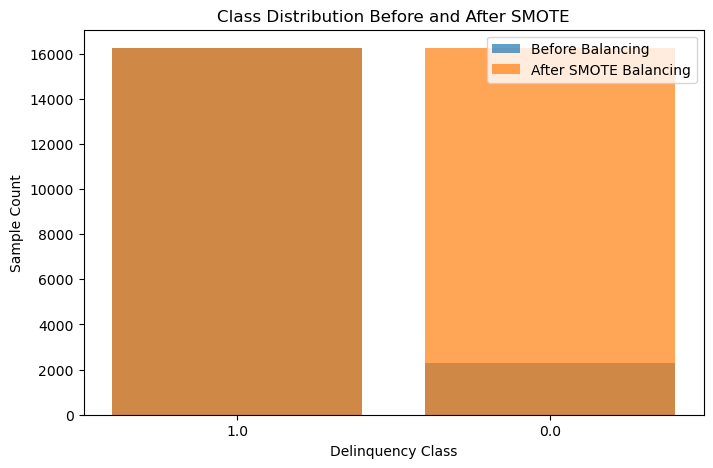

Fitting 3 folds for each of 512 candidates, totalling 1536 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 16248, number of negative: 16248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1325
[LightGBM] [Info] Number of data points in the train set: 32496, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

C:\Users\bog23\AppData\Local\Temp\ipykernel_22672\2000423629.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


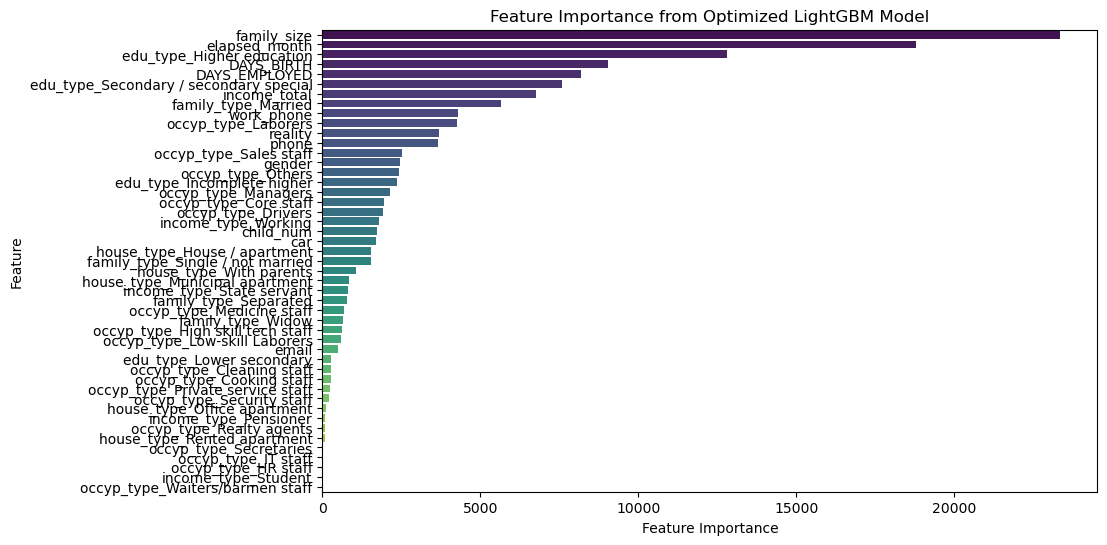

<Figure size 1000x600 with 0 Axes>

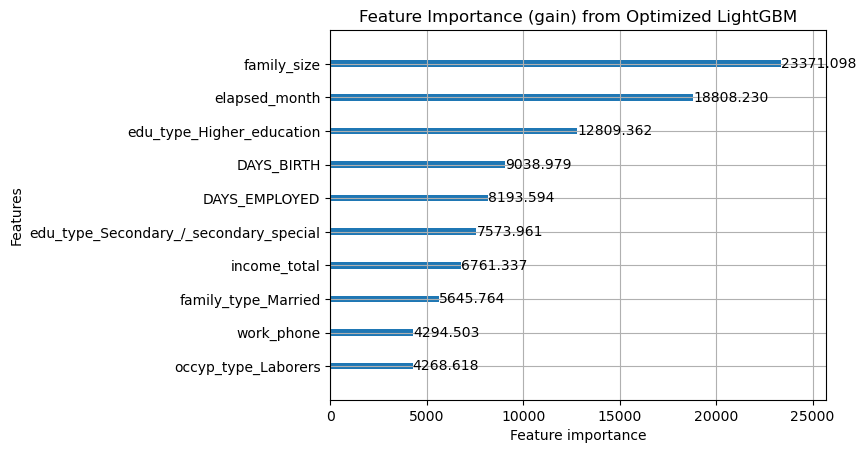

In [1]:
from lightgbm import LGBMClassifier, plot_importance
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("data/processed_credit_data_5.csv")

# 피처와 타겟 변수 분리
X = df.drop(columns=['delinquency', 'index'])
y = df['delinquency']

# 클래스 레이블 재매핑: 0은 그대로 유지, 1과 2는 합쳐서 1로 설정
y = y.replace({1.0: 1, 2.0: 1})

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE 적용 전후의 클래스 분포 확인
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_smote).value_counts()

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(before_counts.index.astype(str), before_counts.values, alpha=0.7, label='Before Balancing')
plt.bar(after_counts.index.astype(str), after_counts.values, alpha=0.7, label='After SMOTE Balancing')
plt.xlabel('Delinquency Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution Before and After SMOTE')
plt.legend()
plt.show()

# X_test의 열을 학습 데이터와 동일하게 정렬
X_test = X_test[X_train_smote.columns]

# 하이퍼파라미터 그리드 간소화
param_grid = {
    'n_estimators': [100, 200],  # 적은 값으로 제한
    'learning_rate': [0.05, 0.1],  # 대표적인 두 값
    'num_leaves': [15, 31],  # 적정 범위 내 값
    'max_depth': [3, 5],  # 최대 깊이 제한
    'min_child_samples': [20, 30],  # 대표적인 두 값
    'subsample': [0.8, 1.0],  # 자주 사용되는 값만 선택
    'colsample_bytree': [0.8, 1.0],  # 자주 사용되는 값만 선택
    'reg_alpha': [0.0, 0.1],  # 규제값 간소화
    'reg_lambda': [0.0, 0.1]  # 규제값 간소화
}

# GridSearchCV 실행
grid_search = GridSearchCV(
    estimator=LGBMClassifier(random_state=0, objective='binary', importance_type='gain'),
    param_grid=param_grid,
    scoring='f1',  # F1 스코어를 기준으로 평가
    cv=3,          # 3-폴드 교차검증
    verbose=2,     # 진행 상황 출력
    n_jobs=-1      # 병렬 처리
)
grid_search.fit(X_train_smote, y_train_smote)

# 최적의 하이퍼파라미터 출력
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# 최적 파라미터로 모델 학습
best_model = grid_search.best_estimator_
best_model.fit(X_train_smote, y_train_smote)

# 테스트 데이터 예측
y_pred = best_model.predict(X_test)

# 모델 평가
print("Classification Report of Optimized LightGBM:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출 및 정리
feature_importances = best_model.feature_importances_
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Optimized LightGBM Model')
plt.show()

# LightGBM 내장 변수 중요도 플롯
plt.figure(figsize=(10, 6))
plot_importance(best_model, max_num_features=10, importance_type='gain')
plt.title("Feature Importance (gain) from Optimized LightGBM")
plt.show()

C:\Users\bog23\anaconda3\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')



클래스 1 (Positive) Summary Plot:


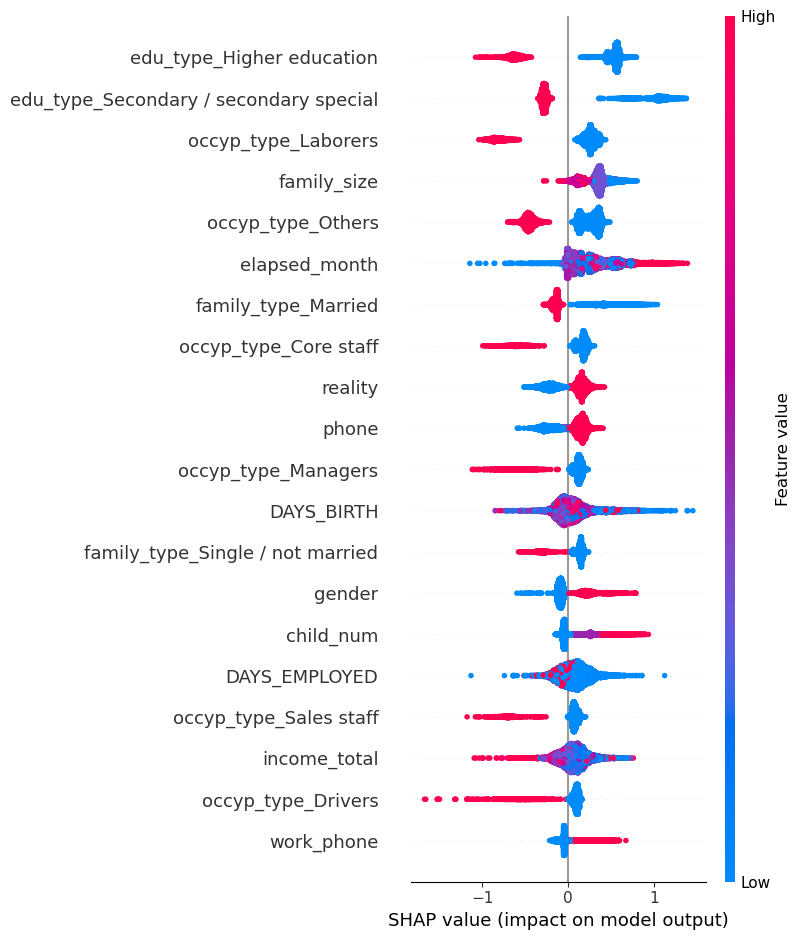

In [3]:
import shap

#SHAP Explainer 생성
explainer = shap.TreeExplainer(best_model)

#SHAP 값 계산
shap_values = explainer.shap_values(X_test)

# 클래스 1 (Positive) SHAP 값
shap_values_class_1 = shap_values

# 클래스 1 Summary Plot
print("\n클래스 1 (Positive) Summary Plot:")
shap.summary_plot(shap_values_class_1, X_test)